## Finalizar o procedimento que faz o reconhecimento facial

# Reconhecimento Facial 


anaconda ambiente 

conda env list

conda activate face-env


trocamos para o ambiente

### no linux: 

só funciona o programa no python  3.10 e na versão opencv 4.5

conda create -n face-env python=3.10 -y

conda activate face-env

pip install opencv-contrib-python==4.5.5.64

pip install opencv-contrib-python==4.5.5.64

conda install jupyter -y

pip install notebook




### Classificação

# geramos a matriz com os históricos das faces


In [17]:
# lbph = cv2.face.LBPHFaceRecognizer_create() # criação padrão
# lbph.train(faces, ids)
# lbph.write('classificador_face_LBPH_aula.yml')  # arquivo em yml criado como base de treinamento das faces, em matriz.

In [18]:
# dados já treinados para fazer a classificação
#classificador_face_LBPH_aula.yml

In [19]:
caminho = "classificador_face_LBPH_aula.yml"

In [20]:
# criando o objeto dessa face
import cv2
print(cv2.__version__)


4.5.5


In [21]:
reconhecedor = cv2.face.LBPHFaceRecognizer_create()
reconhecedor.read(f'{caminho}') # leitura do arquivo, que já carregou no momento.

In [22]:
imagem_teste = 'yalefaces/test/subject10.sad.gif'

In [23]:
# biblioteca para leitura de imagem
from PIL import Image
import numpy as np

In [24]:
imagem = Image.open(imagem_teste).convert('L') # tipo de dados
imagem_np = np.array(imagem, 'uint8') # transformar os dados em matriz e no número inteiro.
print(imagem_np)

[[130 130 130 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 ...
 [255 255 255 ... 241 255 255]
 [255 255 255 ... 234 237 252]
 [ 68  68  68 ...  68  68  68]]


### convertendo a imagem para escala de cinza (grayscale).

'L' significa Luminosidade

Cada pixel passa a ser representado por 1 valor (intensidade de 0 a 255)

0 → preto absoluto

255 → branco absoluto

Ou seja, uma imagem de cor (RGB) que tem 3 canais (Red, Green, Blue) vira uma imagem de 1 canal.

O LBPHFaceRecognizer do OpenCV só funciona bem com imagens em escala de cinza, pois ele analisa padrões de textura, não cor.

In [25]:

# idprevisto, previsão, 15 classes são 15 pessoas da base de treino/teste
idprevisto, _ = reconhecedor.predict(imagem_np)
idprevisto # achou o id correto

10

In [26]:
import os
#verificar a pasta
pasta = "yalefaces/test/"  # nome da pasta
arquivos = os.listdir(pasta)

print(arquivos)

['subject10.centerlight.gif', 'subject03.glasses.gif', 'subject04.surprised.gif', 'subject06.leftlight.gif', 'subject04.leftlight.gif', 'subject12.normal.gif', 'subject15.rightlight.gif', 'subject03.leftlight.gif', 'subject09.sad.gif', 'subject13.sleepy.gif', 'subject08.normal.gif', 'subject07.happy.gif', 'subject08.rightlight.gif', 'subject07.leftlight.gif', 'subject11.glasses.gif', 'subject09.rightlight.gif', 'subject13.sad.gif', 'subject11.happy.gif', 'subject02.leftlight.gif', 'subject01.gif', 'subject05.sleepy.gif', 'subject10.sad.gif', 'subject05.surprised.gif', 'subject14.sad.gif', 'subject12.rightlight.gif', 'subject14.normal.gif', 'subject15.sad.gif', 'subject01.happy.gif', 'subject06.happy.gif', 'subject02.centerlight.gif']


In [27]:
for nome in os.listdir(pasta):
    print(os.path.join(pasta, nome))

yalefaces/test/subject10.centerlight.gif
yalefaces/test/subject03.glasses.gif
yalefaces/test/subject04.surprised.gif
yalefaces/test/subject06.leftlight.gif
yalefaces/test/subject04.leftlight.gif
yalefaces/test/subject12.normal.gif
yalefaces/test/subject15.rightlight.gif
yalefaces/test/subject03.leftlight.gif
yalefaces/test/subject09.sad.gif
yalefaces/test/subject13.sleepy.gif
yalefaces/test/subject08.normal.gif
yalefaces/test/subject07.happy.gif
yalefaces/test/subject08.rightlight.gif
yalefaces/test/subject07.leftlight.gif
yalefaces/test/subject11.glasses.gif
yalefaces/test/subject09.rightlight.gif
yalefaces/test/subject13.sad.gif
yalefaces/test/subject11.happy.gif
yalefaces/test/subject02.leftlight.gif
yalefaces/test/subject01.gif
yalefaces/test/subject05.sleepy.gif
yalefaces/test/subject10.sad.gif
yalefaces/test/subject05.surprised.gif
yalefaces/test/subject14.sad.gif
yalefaces/test/subject12.rightlight.gif
yalefaces/test/subject14.normal.gif
yalefaces/test/subject15.sad.gif
yaleface

In [28]:
# verificar de forma correta, comparção, que já está na nossa base de dados | o que indica que foi classificado corretamente
idcorreto = int(os.path.split(imagem_teste)[1].split('.')[0].replace('subject', ''))
idcorreto

10

In [29]:
x =10
y=10
# posição  (x,y + 30) para escrever o valor na foto do número identificado.
cv2.putText(imagem_np, 'P: ' + str(idprevisto), (x,y + 30), cv2.FONT_HERSHEY_COMPLEX_SMALL, 1, (0,255,0))
# fonte face cv2.FONT_HERSHEY_COMPLEX_SMALL, com o tamanho da escala 1
# qual a cor, preto e branco  azul verde vermelho  (0,255,0)


array([[130, 130, 130, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 241, 255, 255],
       [255, 255, 255, ..., 234, 237, 252],
       [ 68,  68,  68, ...,  68,  68,  68]], dtype=uint8)

In [30]:
from matplotlib import pyplot as plt


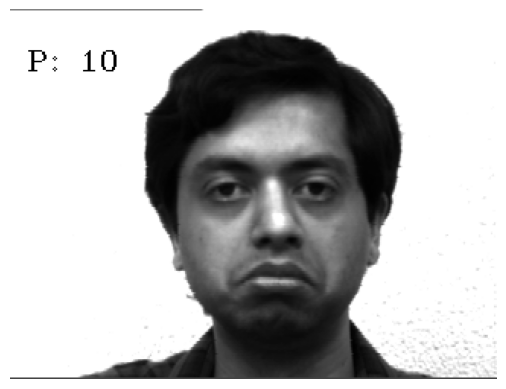

In [31]:
#!pip install matplotlib
plt.imshow(imagem_np, cmap='gray')
plt.axis('off')
plt.show()

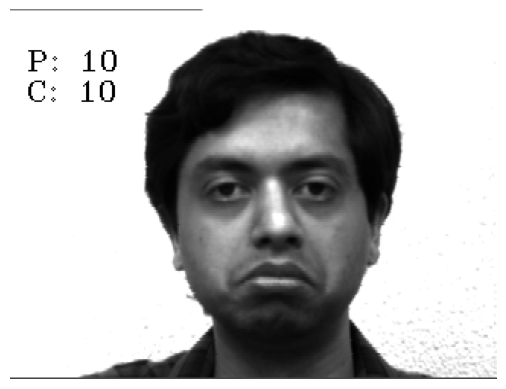

In [32]:
cv2.putText(imagem_np, 'P: ' + str(idprevisto), (x,y + 30), cv2.FONT_HERSHEY_COMPLEX_SMALL, 1, (0,255,0))
cv2.putText(imagem_np, 'C: ' + str(idcorreto), (x,y + 50), cv2.FONT_HERSHEY_COMPLEX_SMALL, 1, (0,255,0))
#cv2_imshow(imagem_np)
# P previsão, C correto
from matplotlib import pyplot as plt

plt.imshow(imagem_np, cmap='gray')
plt.axis('off')
plt.show()

# Verificar o algoritmo nível 2 

[[130 130 130 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 ...
 [255 255 255 ... 249 255 255]
 [255 255 255 ... 255 255 255]
 [ 68  68  68 ...  68  68  68]]
1
1


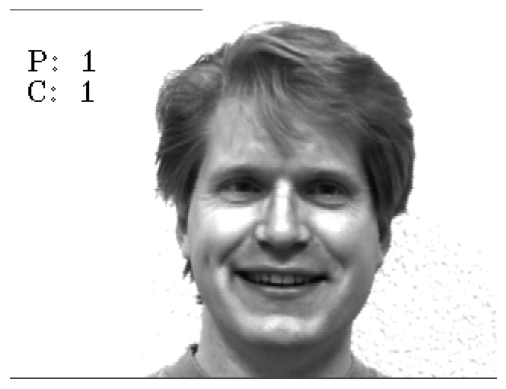

In [38]:
imagem_teste =  'yalefaces/test/subject01.happy.gif'


imagem = Image.open(imagem_teste).convert('L') # tipo de dados
imagem_np = np.array(imagem, 'uint8') # transformar os dados em matriz e no número inteiro.
print(imagem_np)

# idprevisto, previsão, 15 classes são 15 pessoas da base de treino/teste
idprevisto, _ = reconhecedor.predict(imagem_np)
print(idprevisto) # achou o id correto

# verificar de forma correta, comparção, que já está na nossa base de dados | o que indica que foi classificado corretamente
idcorreto = int(os.path.split(imagem_teste)[1].split('.')[0].replace('subject', ''))
print(idcorreto)

cv2.putText(imagem_np, 'P: ' + str(idprevisto), (x,y + 30), cv2.FONT_HERSHEY_COMPLEX_SMALL, 1, (0,255,0))
cv2.putText(imagem_np, 'C: ' + str(idcorreto), (x,y + 50), cv2.FONT_HERSHEY_COMPLEX_SMALL, 1, (0,255,0))
#cv2_imshow(imagem_np)
# P previsão, C correto
from matplotlib import pyplot as plt

plt.imshow(imagem_np, cmap='gray')
plt.axis('off')
plt.show()

[[130 130 130 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 ...
 [255 255 255 ... 182 175 158]
 [246 246 245 ... 168 173 179]
 [ 68  68  68 ...  68  68  68]]
11
11


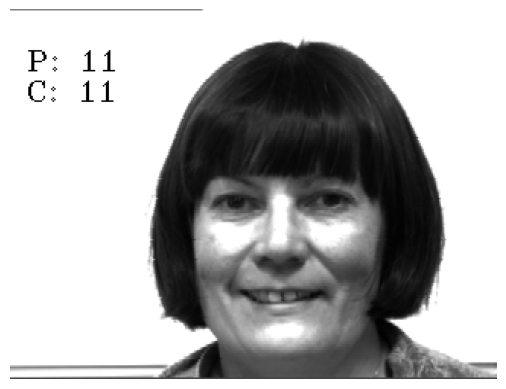

In [39]:
imagem_teste =  'yalefaces/test/subject11.happy.gif'


imagem = Image.open(imagem_teste).convert('L') # tipo de dados
imagem_np = np.array(imagem, 'uint8') # transformar os dados em matriz e no número inteiro.
print(imagem_np)

# idprevisto, previsão, 15 classes são 15 pessoas da base de treino/teste
idprevisto, _ = reconhecedor.predict(imagem_np)
print(idprevisto) # achou o id correto

# verificar de forma correta, comparção, que já está na nossa base de dados | o que indica que foi classificado corretamente
idcorreto = int(os.path.split(imagem_teste)[1].split('.')[0].replace('subject', ''))
print(idcorreto)

cv2.putText(imagem_np, 'P: ' + str(idprevisto), (x,y + 30), cv2.FONT_HERSHEY_COMPLEX_SMALL, 1, (0,255,0))
cv2.putText(imagem_np, 'C: ' + str(idcorreto), (x,y + 50), cv2.FONT_HERSHEY_COMPLEX_SMALL, 1, (0,255,0))
#cv2_imshow(imagem_np)
# P previsão, C correto
from matplotlib import pyplot as plt

plt.imshow(imagem_np, cmap='gray')
plt.axis('off')
plt.show()
